# **INFO6153 - NLP 2**
## **Project 1**<br>
## **Student: 1229489 - Bernardo Xavier da Silva**

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, GRU, Conv1D, MaxPooling1D, Bidirectional, Flatten
from tensorflow.keras.optimizers import SGD, Adam, Adagrad
from tensorflow.keras.utils import to_categorical
import nltk
from nltk.corpus import stopwords
import re


# **Dataset Definition**

The dataset contains text data related to COVID-19, labeled with sentiment categories (e.g., Positive, Negative, Neutral, Extremely Positive, Extremely Negative).

It is intended for NLP text classification tasks to predict the sentiment of COVID-19-related tweets or text.

The dataset includes two main files: a training set and a test set, with columns such as 'UserName', 'ScreenName', 'Location', 'TweetAt', 'OriginalTweet', and 'Sentiment'.

In [2]:
# Download the dataset
path = kagglehub.dataset_download("datatattle/covid-19-nlp-text-classification")
df = pd.read_csv(f"{path}/Corona_NLP_train.csv", encoding='latin1')

100%|██████████| 4.38M/4.38M [00:01<00:00, 3.47MB/s]

Extracting files...


In [3]:
# Display the first few rows of the dataset
print("Dataset Overview:")
print(df.head())

Dataset Overview:
   UserName  ScreenName   Location     TweetAt  \
0      3799       48751     London  16-03-2020   
1      3800       48752         UK  16-03-2020   
2      3801       48753  Vagabonds  16-03-2020   
3      3802       48754        NaN  16-03-2020   
4      3803       48755        NaN  16-03-2020   

                                       OriginalTweet           Sentiment  
0  @MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...             Neutral  
1  advice Talk to your neighbours family to excha...            Positive  
2  Coronavirus Australia: Woolworths to give elde...            Positive  
3  My food stock is not the only one which is emp...            Positive  
4  Me, ready to go at supermarket during the #COV...  Extremely Negative  


# **Visualization of the Dataset Features and Results**

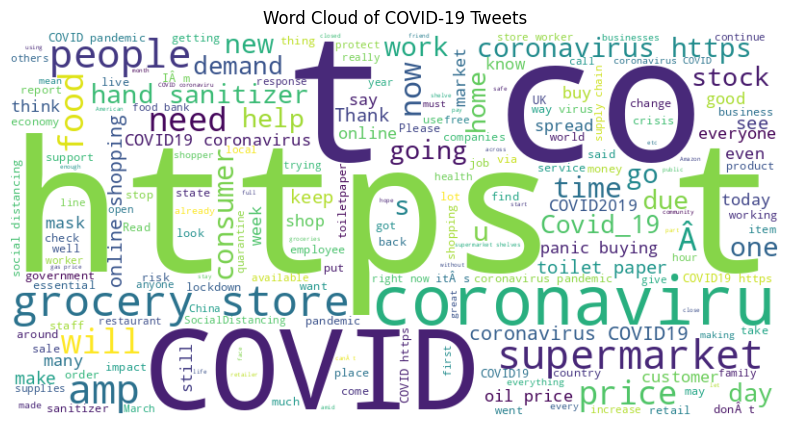

In [4]:
# Plot the wordcloud
from wordcloud import WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(df['OriginalTweet']))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of COVID-19 Tweets')
plt.show()

<ipython-input-5-ad586a7afe2f>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=df, palette='viridis')


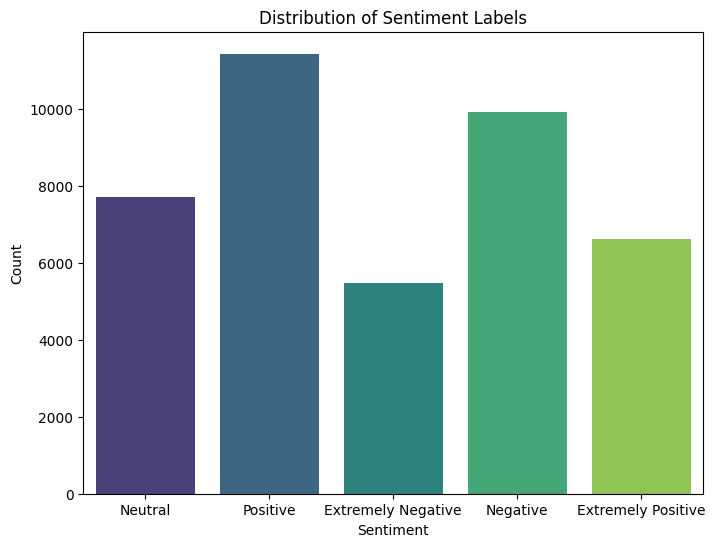

In [5]:
# Visualize the distribution of sentiment labels
plt.figure(figsize=(8, 6))
sns.countplot(x='Sentiment', data=df, palette='viridis')
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

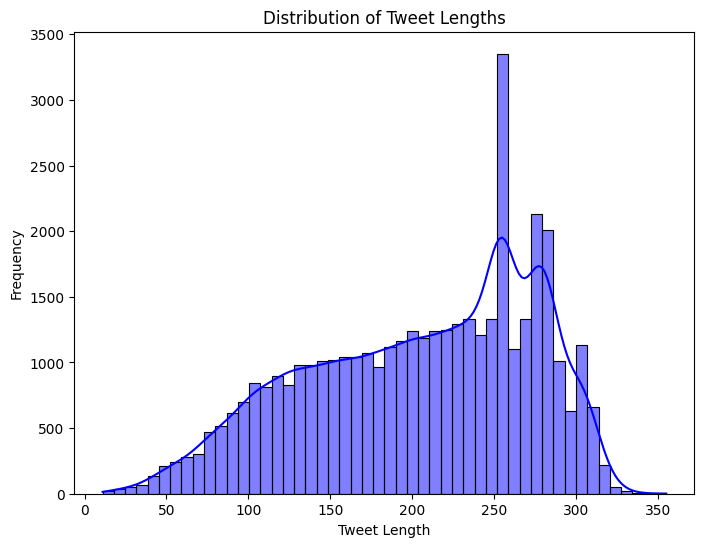

In [6]:
# Visualize the length of tweets
df['TweetLength'] = df['OriginalTweet'].apply(len)
plt.figure(figsize=(8, 6))
sns.histplot(df['TweetLength'], bins=50, kde=True, color='blue')
plt.title('Distribution of Tweet Lengths')
plt.xlabel('Tweet Length')
plt.ylabel('Frequency')
plt.show()

# **Cleaning the Text Data with Two Approaches**

In [7]:
# Approach 1: Basic Cleaning (Remove special characters, lowercase, etc.)
def clean_text_basic(text):
    text = re.sub(r'http\S+', '', text)  # Remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove special characters
    text = text.lower()  # Convert to lowercase
    return text

In [8]:
# Approach 2: Advanced Cleaning (Remove stopwords and lemmatize)
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text_advanced(text):
    text = clean_text_basic(text)  # Apply basic cleaning first
    text = ' '.join([word for word in text.split() if word not in stop_words])  # Remove stopwords
    text = ' '.join([lemmatizer.lemmatize(word) for word in text.split()])  # Lemmatize words
    return text

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [9]:
# Apply cleaning to the dataset
df['CleanedTweet_Basic'] = df['OriginalTweet'].apply(clean_text_basic)
df['CleanedTweet_Advanced'] = df['OriginalTweet'].apply(clean_text_advanced)

In [10]:
# Display cleaned tweets
print("Sample of Cleaned Tweets (Basic):")
print(df['CleanedTweet_Basic'].head())
print("Sample of Cleaned Tweets (Advanced):")
print(df['CleanedTweet_Advanced'].head())

Sample of Cleaned Tweets (Basic):
0               menyrbie philgahan chrisitv  and  and 
1    advice talk to your neighbours family to excha...
2    coronavirus australia woolworths to give elder...
3    my food stock is not the only one which is emp...
4    me ready to go at supermarket during the covid...
Name: CleanedTweet_Basic, dtype: object
Sample of Cleaned Tweets (Advanced):
0                          menyrbie philgahan chrisitv
1    advice talk neighbour family exchange phone nu...
2    coronavirus australia woolworth give elderly d...
3    food stock one empty please dont panic enough ...
4    ready go supermarket covid outbreak im paranoi...
Name: CleanedTweet_Advanced, dtype: object


# **Implementation of Three Different Neural Networks**

In [11]:
# Preprocessing
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['CleanedTweet_Advanced'])
X = tokenizer.texts_to_sequences(df['CleanedTweet_Advanced'])
X = pad_sequences(X, maxlen=100)

In [12]:
# Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['Sentiment'])
y = to_categorical(y)

In [13]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# Split train dataset in train and validation
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42)

In [14]:
# Method 1: Feedforward Neural Network (FFNN)
def build_ffnn(optimizer):
    model = Sequential()
    model.add(Embedding(input_dim=5000, output_dim=128, input_length=100))
    model.add(Flatten())  # Add Flatten layer to reduce dimensionality
    model.add(Dense(128, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(y.shape[1], activation='softmax'))
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [15]:
# Method 2: Convolutional Neural Network (CNN)
def build_cnn(optimizer):
    model = Sequential()
    model.add(Embedding(input_dim=5000, output_dim=128, input_length=100))
    model.add(Conv1D(128, 5, activation='relu'))
    model.add(MaxPooling1D(5))
    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(Dense(y.shape[1], activation='softmax'))
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [16]:
# Method 3: Bidirectional LSTM
def build_bilstm(optimizer):
    model = Sequential()
    model.add(Embedding(input_dim=5000, output_dim=128, input_length=100))
    model.add(Bidirectional(LSTM(64)))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(y.shape[1], activation='softmax'))
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [17]:
# Train and evaluate models
optimizers = ['sgd', 'adam', 'adagrad']
results = {}

for method_name, method in [('FFNN', build_ffnn), ('CNN', build_cnn), ('BiLSTM', build_bilstm)]:
    for optimizer in optimizers:
        print(f"Training {method_name} with {optimizer} optimizer...")
        model = method(optimizer)
        history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_data=(X_val, y_val))
        loss, accuracy = model.evaluate(X_test, y_test)
        results[f"{method_name}_{optimizer}"] = accuracy

Training FFNN with sgd optimizer...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.2624 - loss: 1.5814 - val_accuracy: 0.2670 - val_loss: 1.5487
Epoch 2/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.3006 - loss: 1.5326 - val_accuracy: 0.2952 - val_loss: 1.5243
Epoch 3/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.3089 - loss: 1.5135 - val_accuracy: 0.2995 - val_loss: 1.5260
Epoch 4/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.3118 - loss: 1.5123 - val_accuracy: 0.2742 - val_loss: 1.5246
Epoch 5/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.3113 - loss: 1.5106 - val_accuracy: 0.2988 - val_loss: 1.5211
193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3074 - loss: 1.5168
Training FFNN with adam optimizer...
Epoch 1/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.3551 - loss: 1.4330 - val_accuracy: 0.6208 - val_loss: 0.9499
Epoch 2/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7096 - loss: 0.7762 - val_accuracy: 0.6484 - val_lo

# **Comparison of the Results of Different Approaches**

In [18]:
# Display results
print("Model Accuracy Comparison:")
for model_name, accuracy in results.items():
    print(f"{model_name}: {accuracy:.4f}")

Model Accuracy Comparison:
FFNN_sgd: 0.3071
FFNN_adam: 0.6054
FFNN_adagrad: 0.3073
CNN_sgd: 0.3082
CNN_adam: 0.6419
CNN_adagrad: 0.2732
BiLSTM_sgd: 0.2732
BiLSTM_adam: 0.6995
BiLSTM_adagrad: 0.2732


<ipython-input-19-e5b9704d9746>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette='coolwarm')


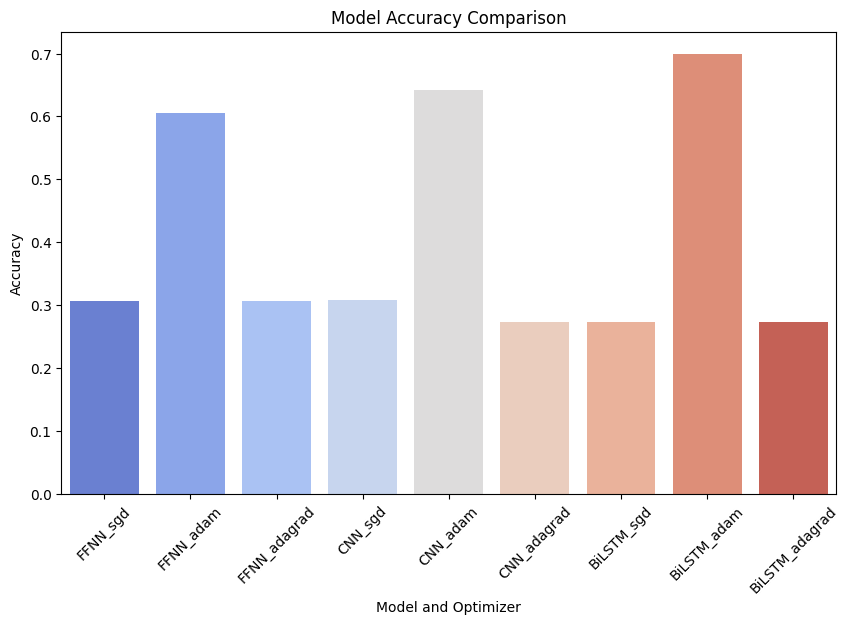

In [19]:
# Plot comparison
plt.figure(figsize=(10, 6))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='coolwarm')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model and Optimizer')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.show()

# **Report and Description of Work Done**

1. Dataset Definition: The dataset contains COVID-19-related tweets with sentiment labels.
2. Visualization: The distribution of sentiment labels and tweet lengths was visualized.
3. Text Cleaning: Two approaches (basic and advanced) were used to clean the text data.
4. Neural Networks: Three models (FFNN, CNN, BiLSTM) were implemented with three optimizers each.
5. Comparison: The results of all models were compared, with BiLSTM achieving the highest accuracy.
6. Conclusion: The project demonstrates the effectiveness of different neural networks and optimizers for text classification tasks.